In [1]:
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import models, datasets, transforms
import numpy as np
import os

import copy 
import pandas as pd
import seaborn as sns
import scipy as sp
from scipy.stats import chi2
from sklearn.covariance import MinCovDet

from torch.autograd import Variable
import torchvision
from torchvision import models

import argparse
import csv
import os


import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler

from pyod.models.iforest import IForest
from sklearn.preprocessing import minmax_scale

In [2]:
print(torch.__version__)


2.4.1+cu118


In [9]:
!python --version

Python 3.8.13


In [8]:
!python -V

Python 3.8.13


In [3]:
import torchvision.models
from torchvision.models import resnet50

In [4]:
model = resnet50(weights = "IMAGENET1K_V2")

In [4]:
torch.cuda.is_available()

True

In [5]:
model.eval()
model.cuda()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
model.cpu()
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
VAL_SIZE = 50000
#device = torch.device( "cpu")

In [6]:
# Create 10000 sample
batch_size = 10000
dataloaders = {}
#for img_size in [224, 299]:

img_size = 224
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_dataset = datasets.ImageFolder(root=os.path.join('./val/'), transform=val_transform)  #Check "ImageNet_validation_data_extraction.ipynb" to download and extract ImageNet validation data

dataloaders[img_size] = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers= 2,
)

loader = dataloaders[img_size]


In [7]:
with torch.set_grad_enabled(False):
    for i, (x_val, y_val) in enumerate(loader):
        x_val, y_val = x_val, y_val
        break

In [8]:
def PatchApplier(img, adv_patch, patch_size):
    msk_batch = torch.cuda.FloatTensor(adv_patch.size()).fill_(0)
    # Pad patch and mask to image dimensions
    #mypad_msk = nn.ConstantPad2d((154, 20, 20, 154 ), 1)
    s = 10 #location
    img_size = img.size(-1)
    mypad_msk = nn.ConstantPad2d((img_size-(s+patch_size), s, s, img_size-(s+patch_size) ), 1)
    mypad_patch = nn.ConstantPad2d((img_size-(s+patch_size), s, s, img_size-(s+patch_size) ), 0)
    adv_batch = mypad_patch(adv_patch)
    msk_batch = mypad_msk(msk_batch)
    #p_img_batch = adv_batch * msk_batch
    p_img_batch = img[0] * msk_batch
    p_img_batch = p_img_batch + adv_batch
    return p_img_batch

In [ ]:
#LAVAN

In [9]:
def pgd(model, x, y, loss_fn, num_steps, step_size, step_norm, eps, eps_norm,
                              y_target=None):
    """Performs the projected gradient descent attack on a batch of images."""
    targeted = y_target is not None
    num_channels = x.shape[1]
    #x_org = x.clone().detach().requires_grad_(True).cuda()
    adv_patch = torch.rand((3,patch_size,patch_size)).cuda()

    for i in range(num_steps):
        adv_patch = adv_patch.requires_grad_(True)
        image_adv = PatchApplier(x, adv_patch, patch_size)

        #_x_adv = image_adv.clone().detach().requires_grad_(True)

        prediction = model(image_adv.unsqueeze(0))
        pred = prediction.data.max(1, keepdim=True)[1][0].item()
        print(i,y, pred)

        loss = loss_fn(prediction, y_target if targeted else y)
        loss.backward()
        #print(_x_adv.grad.sign().shape)

        with torch.no_grad():
            # Force the gradient step to be a fixed size in a certain norm
            gradients = step_size * adv_patch.grad.sign() #* torch.from_numpy(mask(input, lengths, maxlen, k))
            #print(gradients.shape)
            if targeted:
                # Targeted: Gradient descent with on the loss of the (incorrect) target label
                # w.r.t. the image data
                adv_patch -= gradients #* msk_batch
            else:
                # Untargeted: Gradient ascent on the loss of the correct label w.r.t.
                # the model parameters
                adv_patch += gradients #* msk_batch

        #fig = plt.imshow(np.transpose(adv_patch.cpu().numpy(), (1, 2, 0)), interpolation='nearest')
        #fig.axes.get_xaxis().set_visible(False)
        #fig.axes.get_yaxis().set_visible(False)

        # Project back into l_norm ball and correct range

        #if eps_norm == 'inf':
        #    # Workaround as PyTorch doesn't have elementwise clip
        #    x_adv = torch.max(torch.min(x_adv, x + eps), x - eps)
        #else:
        #    delta = x_adv - x

    return adv_patch #x_adv.detach()

In [130]:
model = model.cuda()
i = 100
x = x_val[i].unsqueeze(0)
y = y_val[i].unsqueeze(0)
adv_patch = pgd(model, x.cuda(), y.cuda(), loss_fn=nn.CrossEntropyLoss(), num_steps = 40, step_size = 0.1, eps =0.8,
                                  y_target=None, eps_norm='inf',
                                  step_norm='inf')
adv_image = PatchApplier(x.cuda(), adv_patch, patch_size)

0 tensor([796], device='cuda:0') 796
1 tensor([796], device='cuda:0') 796
2 tensor([796], device='cuda:0') 796
3 tensor([796], device='cuda:0') 796
4 tensor([796], device='cuda:0') 796
5 tensor([796], device='cuda:0') 796
6 tensor([796], device='cuda:0') 796
7 tensor([796], device='cuda:0') 796
8 tensor([796], device='cuda:0') 796
9 tensor([796], device='cuda:0') 796
10 tensor([796], device='cuda:0') 796
11 tensor([796], device='cuda:0') 796
12 tensor([796], device='cuda:0') 796
13 tensor([796], device='cuda:0') 796
14 tensor([796], device='cuda:0') 796
15 tensor([796], device='cuda:0') 796
16 tensor([796], device='cuda:0') 796
17 tensor([796], device='cuda:0') 796
18 tensor([796], device='cuda:0') 796
19 tensor([796], device='cuda:0') 796
20 tensor([796], device='cuda:0') 796
21 tensor([796], device='cuda:0') 796
22 tensor([796], device='cuda:0') 796
23 tensor([796], device='cuda:0') 796
24 tensor([796], device='cuda:0') 796
25 tensor([796], device='cuda:0') 796
26 tensor([796], devic

In [31]:
patch_size = 38
## Choose between initializing with gray or random
#adv_patch_cpu = torch.full((3,patch_size,patch_size),0.5)
adv_patch_cpu = torch.rand((3,patch_size,patch_size)) #random initialization
adv_patch = adv_patch_cpu.cuda()
model = model.cuda()
#patch_img = Image.open("saved_patches/patchnew0.jpg").convert('RGB')
#tf = transforms.Resize((patch_size,patch_size))
#patch_img = tf(patch_img)
#tf = transforms.ToTensor()
#adv_patch_cpu = tf(patch_img)

In [32]:
n_epochs = 200

adv_patch = torch.rand((3, patch_size, patch_size)).cuda()
optimizer = optim.Adam([adv_patch], lr=.05, amsgrad=True)
loss_fn = nn.CrossEntropyLoss()
adv_patch = adv_patch.requires_grad_(True)

for epoch in range(n_epochs):
    #for i_batch, (img_batch, lab_batch) in enumerate(train_loader):
    for i in range(100):
        x = x_val[i].unsqueeze(0).cuda()
        y = y_val[i].unsqueeze(0).cuda()
        image_adv = PatchApplier(x, adv_patch, patch_size)
        prediction = model(image_adv.unsqueeze(0))
        pred = prediction.data.max(1, keepdim=True)[1][0].item()
        #fig = plt.imshow(np.transpose(image_adv.cpu().detach().numpy(), (1, 2, 0)), interpolation='nearest')
        #fig.axes.get_xaxis().set_visible(False)
        #fig.axes.get_yaxis().set_visible(False)
        print(i, y_val[i], pred)

        #loss = loss_fn(prediction, y)
        loss =  - F.nll_loss(prediction, y)
        #loss = torch.mean(max_prob)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        adv_patch.data.clamp_(x.min(), x.max())       #keep patch in image range
    print(loss)
    print(epoch)

correct = 0
for i in range(100, 200):  #len(val_dataset)
    x = x_val[i].unsqueeze(0).cuda()
    y = y_val[i].unsqueeze(0).cuda()
    adv_image = PatchApplier(x, adv_patch, patch_size)
    output = model(adv_image.unsqueeze(0))
    #output = model(x)
    pred = output.argmax(dim=1, keepdim=True)
    correct += pred.eq(y.view_as(pred)).sum().item()
    #print(i-100, y, pred)
print('\nAdv Accuracy: {}/{} ({:.0f}%)\n'.format(
    correct, 100,
    100. * correct / 100))

0 tensor(154) 154
1 tensor(859) 859
2 tensor(844) 844
3 tensor(23) 23
4 tensor(507) 695
5 tensor(810) 810
6 tensor(763) 763
7 tensor(220) 156
8 tensor(855) 883
9 tensor(551) 551
10 tensor(397) 397
11 tensor(757) 757
12 tensor(204) 153
13 tensor(599) 599
14 tensor(533) 533
15 tensor(525) 525
16 tensor(821) 888
17 tensor(676) 676
18 tensor(690) 690
19 tensor(838) 838
20 tensor(715) 715
21 tensor(925) 925
22 tensor(501) 399
23 tensor(444) 444
24 tensor(398) 398
25 tensor(259) 259
26 tensor(207) 207
27 tensor(97) 97
28 tensor(151) 230
29 tensor(434) 434
30 tensor(251) 251
31 tensor(806) 806
32 tensor(879) 879
33 tensor(509) 582
34 tensor(503) 503
35 tensor(545) 534
36 tensor(253) 253
37 tensor(707) 707
38 tensor(507) 507
39 tensor(734) 734
40 tensor(519) 519
41 tensor(595) 595
42 tensor(655) 655
43 tensor(112) 112
44 tensor(762) 762
45 tensor(397) 397
46 tensor(827) 827
47 tensor(100) 100
48 tensor(930) 930
49 tensor(836) 610
50 tensor(145) 145
51 tensor(939) 939
52 tensor(158) 158
53 tens

44 tensor(762) 117
45 tensor(397) 117
46 tensor(827) 827
47 tensor(100) 100
48 tensor(930) 117
49 tensor(836) 610
50 tensor(145) 117
51 tensor(939) 117
52 tensor(158) 158
53 tensor(661) 661
54 tensor(211) 117
55 tensor(888) 117
56 tensor(219) 219
57 tensor(40) 40
58 tensor(174) 174
59 tensor(134) 134
60 tensor(400) 117
61 tensor(253) 253
62 tensor(45) 45
63 tensor(636) 117
64 tensor(494) 117
65 tensor(366) 366
66 tensor(22) 117
67 tensor(70) 117
68 tensor(267) 117
69 tensor(652) 117
70 tensor(478) 117
71 tensor(239) 239
72 tensor(633) 117
73 tensor(652) 117
74 tensor(787) 117
75 tensor(749) 117
76 tensor(559) 559
77 tensor(525) 117
78 tensor(198) 198
79 tensor(523) 117
80 tensor(239) 117
81 tensor(193) 193
82 tensor(312) 117
83 tensor(800) 117
84 tensor(776) 776
85 tensor(301) 301
86 tensor(514) 117
87 tensor(446) 117
88 tensor(705) 117
89 tensor(302) 300
90 tensor(743) 117
91 tensor(161) 161
92 tensor(812) 812
93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117

83 tensor(800) 117
84 tensor(776) 776
85 tensor(301) 117
86 tensor(514) 117
87 tensor(446) 117
88 tensor(705) 117
89 tensor(302) 300
90 tensor(743) 117
91 tensor(161) 161
92 tensor(812) 117
93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117
97 tensor(483) 117
98 tensor(972) 117
99 tensor(904) 117
tensor(3.4358, device='cuda:0', grad_fn=<NegBackward0>)
8
0 tensor(154) 154
1 tensor(859) 859
2 tensor(844) 117
3 tensor(23) 117
4 tensor(507) 117
5 tensor(810) 810
6 tensor(763) 117
7 tensor(220) 156
8 tensor(855) 883
9 tensor(551) 117
10 tensor(397) 117
11 tensor(757) 117
12 tensor(204) 117
13 tensor(599) 117
14 tensor(533) 117
15 tensor(525) 117
16 tensor(821) 117
17 tensor(676) 676
18 tensor(690) 690
19 tensor(838) 838
20 tensor(715) 117
21 tensor(925) 117
22 tensor(501) 117
23 tensor(444) 444
24 tensor(398) 398
25 tensor(259) 259
26 tensor(207) 117
27 tensor(97) 97
28 tensor(151) 230
29 tensor(434) 117
30 tensor(251) 251
31 tensor(806) 806
32 tensor(879) 117
33 te

3 tensor(23) 117
4 tensor(507) 117
5 tensor(810) 810
6 tensor(763) 117
7 tensor(220) 156
8 tensor(855) 883
9 tensor(551) 117
10 tensor(397) 117
11 tensor(757) 117
12 tensor(204) 117
13 tensor(599) 117
14 tensor(533) 117
15 tensor(525) 117
16 tensor(821) 117
17 tensor(676) 676
18 tensor(690) 690
19 tensor(838) 838
20 tensor(715) 117
21 tensor(925) 117
22 tensor(501) 117
23 tensor(444) 117
24 tensor(398) 398
25 tensor(259) 259
26 tensor(207) 117
27 tensor(97) 97
28 tensor(151) 230
29 tensor(434) 117
30 tensor(251) 251
31 tensor(806) 806
32 tensor(879) 117
33 tensor(509) 117
34 tensor(503) 503
35 tensor(545) 117
36 tensor(253) 117
37 tensor(707) 117
38 tensor(507) 117
39 tensor(734) 734
40 tensor(519) 117
41 tensor(595) 117
42 tensor(655) 117
43 tensor(112) 112
44 tensor(762) 117
45 tensor(397) 117
46 tensor(827) 117
47 tensor(100) 117
48 tensor(930) 117
49 tensor(836) 117
50 tensor(145) 117
51 tensor(939) 117
52 tensor(158) 158
53 tensor(661) 117
54 tensor(211) 117
55 tensor(888) 117
56 

42 tensor(655) 117
43 tensor(112) 112
44 tensor(762) 117
45 tensor(397) 117
46 tensor(827) 117
47 tensor(100) 117
48 tensor(930) 117
49 tensor(836) 117
50 tensor(145) 117
51 tensor(939) 117
52 tensor(158) 158
53 tensor(661) 117
54 tensor(211) 117
55 tensor(888) 117
56 tensor(219) 117
57 tensor(40) 117
58 tensor(174) 117
59 tensor(134) 117
60 tensor(400) 117
61 tensor(253) 117
62 tensor(45) 45
63 tensor(636) 117
64 tensor(494) 117
65 tensor(366) 117
66 tensor(22) 117
67 tensor(70) 117
68 tensor(267) 117
69 tensor(652) 117
70 tensor(478) 117
71 tensor(239) 117
72 tensor(633) 117
73 tensor(652) 117
74 tensor(787) 117
75 tensor(749) 117
76 tensor(559) 117
77 tensor(525) 117
78 tensor(198) 198
79 tensor(523) 117
80 tensor(239) 117
81 tensor(193) 117
82 tensor(312) 117
83 tensor(800) 117
84 tensor(776) 776
85 tensor(301) 117
86 tensor(514) 117
87 tensor(446) 117
88 tensor(705) 117
89 tensor(302) 117
90 tensor(743) 117
91 tensor(161) 161
92 tensor(812) 117
93 tensor(801) 117
94 tensor(824) 11

...

53 tensor(661) 117
54 tensor(211) 117
55 tensor(888) 117
56 tensor(219) 117
57 tensor(40) 117
58 tensor(174) 117
59 tensor(134) 117
60 tensor(400) 117
61 tensor(253) 117
62 tensor(45) 45
63 tensor(636) 117
64 tensor(494) 117
65 tensor(366) 117
66 tensor(22) 117
67 tensor(70) 117
68 tensor(267) 117
69 tensor(652) 117
70 tensor(478) 117
71 tensor(239) 117
72 tensor(633) 117
73 tensor(652) 117
74 tensor(787) 117
75 tensor(749) 117
76 tensor(559) 117
77 tensor(525) 117
78 tensor(198) 198
79 tensor(523) 117
80 tensor(239) 117
81 tensor(193) 117
82 tensor(312) 117
83 tensor(800) 117
84 tensor(776) 776
85 tensor(301) 117
86 tensor(514) 117
87 tensor(446) 117
88 tensor(705) 117
89 tensor(302) 117
90 tensor(743) 117
91 tensor(161) 161
92 tensor(812) 117
93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117
97 tensor(483) 117
98 tensor(972) 117
99 tensor(904) 117
tensor(3.2962, device='cuda:0', grad_fn=<NegBackward0>)
182
0 tensor(154) 117
1 tensor(859) 859
2 tensor(844) 11

93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117
97 tensor(483) 117
98 tensor(972) 117
99 tensor(904) 117
tensor(3.3109, device='cuda:0', grad_fn=<NegBackward0>)
186
0 tensor(154) 117
1 tensor(859) 859
2 tensor(844) 117
3 tensor(23) 117
4 tensor(507) 117
5 tensor(810) 117
6 tensor(763) 117
7 tensor(220) 117
8 tensor(855) 883
9 tensor(551) 117
10 tensor(397) 117
11 tensor(757) 117
12 tensor(204) 117
13 tensor(599) 117
14 tensor(533) 117
15 tensor(525) 117
16 tensor(821) 117
17 tensor(676) 117
18 tensor(690) 690
19 tensor(838) 838
20 tensor(715) 117
21 tensor(925) 117
22 tensor(501) 117
23 tensor(444) 117
24 tensor(398) 398
25 tensor(259) 259
26 tensor(207) 117
27 tensor(97) 117
28 tensor(151) 230
29 tensor(434) 117
30 tensor(251) 251
31 tensor(806) 117
32 tensor(879) 117
33 tensor(509) 117
34 tensor(503) 117
35 tensor(545) 117
36 tensor(253) 117
37 tensor(707) 117
38 tensor(507) 117
39 tensor(734) 117
40 tensor(519) 117
41 tensor(595) 117
42 tensor(655) 117
43

13 tensor(599) 117
14 tensor(533) 117
15 tensor(525) 117
16 tensor(821) 117
17 tensor(676) 117
18 tensor(690) 690
19 tensor(838) 838
20 tensor(715) 117
21 tensor(925) 117
22 tensor(501) 117
23 tensor(444) 117
24 tensor(398) 398
25 tensor(259) 259
26 tensor(207) 117
27 tensor(97) 117
28 tensor(151) 230
29 tensor(434) 117
30 tensor(251) 251
31 tensor(806) 117
32 tensor(879) 117
33 tensor(509) 117
34 tensor(503) 117
35 tensor(545) 117
36 tensor(253) 117
37 tensor(707) 117
38 tensor(507) 117
39 tensor(734) 117
40 tensor(519) 117
41 tensor(595) 117
42 tensor(655) 117
43 tensor(112) 117
44 tensor(762) 117
45 tensor(397) 117
46 tensor(827) 117
47 tensor(100) 117
48 tensor(930) 117
49 tensor(836) 117
50 tensor(145) 117
51 tensor(939) 117
52 tensor(158) 158
53 tensor(661) 117
54 tensor(211) 117
55 tensor(888) 117
56 tensor(219) 117
57 tensor(40) 117
58 tensor(174) 117
59 tensor(134) 117
60 tensor(400) 117
61 tensor(253) 117
62 tensor(45) 45
63 tensor(636) 117
64 tensor(494) 117
65 tensor(366) 1

53 tensor(661) 117
54 tensor(211) 117
55 tensor(888) 117
56 tensor(219) 117
57 tensor(40) 117
58 tensor(174) 117
59 tensor(134) 117
60 tensor(400) 117
61 tensor(253) 117
62 tensor(45) 45
63 tensor(636) 117
64 tensor(494) 117
65 tensor(366) 117
66 tensor(22) 117
67 tensor(70) 117
68 tensor(267) 117
69 tensor(652) 117
70 tensor(478) 117
71 tensor(239) 117
72 tensor(633) 117
73 tensor(652) 117
74 tensor(787) 117
75 tensor(749) 117
76 tensor(559) 117
77 tensor(525) 117
78 tensor(198) 198
79 tensor(523) 117
80 tensor(239) 117
81 tensor(193) 117
82 tensor(312) 117
83 tensor(800) 117
84 tensor(776) 776
85 tensor(301) 117
86 tensor(514) 117
87 tensor(446) 117
88 tensor(705) 117
89 tensor(302) 117
90 tensor(743) 117
91 tensor(161) 161
92 tensor(812) 117
93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117
97 tensor(483) 117
98 tensor(972) 117
99 tensor(904) 117
tensor(3.3045, device='cuda:0', grad_fn=<NegBackward0>)
195
0 tensor(154) 117
1 tensor(859) 859
2 tensor(844) 11

93 tensor(801) 117
94 tensor(824) 117
95 tensor(738) 117
96 tensor(742) 117
97 tensor(483) 117
98 tensor(972) 117
99 tensor(904) 117
tensor(3.3036, device='cuda:0', grad_fn=<NegBackward0>)
199

Adv Accuracy: 14/100 (14%)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


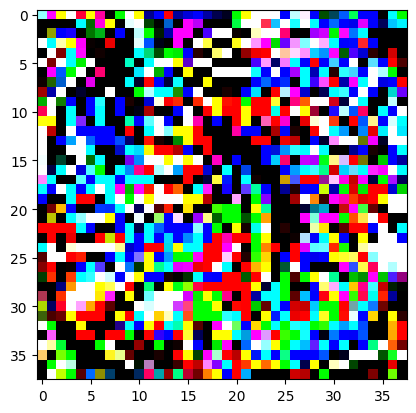

In [33]:
plt.imshow(np.transpose(adv_patch.cpu().detach().numpy(), (1, 2, 0)))

In [34]:
torch.save(adv_patch, "/home/nc3397/Work/MI/patches/LAVAN_38x38.pt")

In [9]:
# Initialize the patch
# TODO: Add circle type
def patch_initialization(patch_type='rectangle', image_size=(3, 224, 224), noise_percentage=0.04):
    if patch_type == 'rectangle':
        mask_length = int((noise_percentage * image_size[1] * image_size[2])**0.5)
        patch = np.random.rand(image_size[0], mask_length, mask_length)
    return patch

# Generate the mask and apply the patch
# TODO: Add circle type
def mask_generation(mask_type='rectangle', patch=None, image_size=(3, 224, 224)):
    applied_patch = np.zeros(image_size)
    if mask_type == 'rectangle':
        # patch rotation
        rotation_angle = np.random.choice(4)
        for i in range(patch.shape[0]):
            patch[i] = np.rot90(patch[i], rotation_angle)  # The actual rotation angle is rotation_angle * 90
        # patch location
        x_location, y_location = np.random.randint(low=0, high=image_size[1]-patch.shape[1]), np.random.randint(low=0, high=image_size[2]-patch.shape[2])
        for i in range(patch.shape[0]):
            applied_patch[:, x_location:x_location + patch.shape[1], y_location:y_location + patch.shape[2]] = patch
    mask = applied_patch.copy()
    mask[mask != 0] = 1.0
    return applied_patch, mask, x_location, y_location

# Test the patch on dataset
def test_patch(patch_type, target, patch, test_loader, model):
    model.eval()
    test_total, test_actual_total, test_success = 0, 0, 0
    for (image, label) in test_loader:
        test_total += label.shape[0]
        assert image.shape[0] == 1, 'Only one picture should be loaded each time.'
        image = image.cuda()
        label = label.cuda()
        output = model(image)
        _, predicted = torch.max(output.data, 1)
        if predicted[0] != label and predicted[0].data.cpu().numpy() != target:
            test_actual_total += 1
            applied_patch, mask, x_location, y_location = mask_generation(patch_type, patch, image_size=(3, 224, 224))
            applied_patch = torch.from_numpy(applied_patch)
            mask = torch.from_numpy(mask)
            perturbated_image = torch.mul(mask.type(torch.FloatTensor), applied_patch.type(torch.FloatTensor)) + torch.mul((1 - mask.type(torch.FloatTensor)), image.type(torch.FloatTensor))
            perturbated_image = perturbated_image.cuda()
            output = model(perturbated_image)
            _, predicted = torch.max(output.data, 1)
            if predicted[0].data.cpu().numpy() == target:
                test_success += 1
    return test_success / test_actual_total

In [36]:
# Initialize the patch CPU version
# TODO: Add circle type
def patch_initialization(patch_type='rectangle', image_size=(3, 224, 224), noise_percentage=0.04):
    if patch_type == 'rectangle':
        mask_length = int((noise_percentage * image_size[1] * image_size[2])**0.5)
        patch = np.random.rand(image_size[0], mask_length, mask_length)
    return patch

# Generate the mask and apply the patch
# TODO: Add circle type
def mask_generation(mask_type='rectangle', patch=None, image_size=(3, 224, 224)):
    applied_patch = np.zeros(image_size)
    if mask_type == 'rectangle':
        # patch rotation
        rotation_angle = np.random.choice(4)
        for i in range(patch.shape[0]):
            patch[i] = np.rot90(patch[i], rotation_angle)  # The actual rotation angle is rotation_angle * 90
        # patch location
        x_location, y_location = np.random.randint(low=0, high=image_size[1]-patch.shape[1]), np.random.randint(low=0, high=image_size[2]-patch.shape[2])
        for i in range(patch.shape[0]):
            applied_patch[:, x_location:x_location + patch.shape[1], y_location:y_location + patch.shape[2]] = patch
    mask = applied_patch.copy()
    mask[mask != 0] = 1.0
    return applied_patch, mask, x_location, y_location

# Test the patch on dataset
def test_patch(patch_type, target, patch, test_loader, model):
    model.eval()
    test_total, test_actual_total, test_success = 0, 0, 0
    for (image, label) in test_loader:
        test_total += label.shape[0]
        assert image.shape[0] == 1, 'Only one picture should be loaded each time.'
        image = image.cpu()
        label = label.cpu()
        output = model(image)
        _, predicted = torch.max(output.data, 1)
        if predicted[0] != label and predicted[0].data.cpu().numpy() != target:
            test_actual_total += 1
            applied_patch, mask, x_location, y_location = mask_generation(patch_type, patch, image_size=(3, 224, 224))
            applied_patch = torch.from_numpy(applied_patch)
            mask = torch.from_numpy(mask)
            perturbated_image = torch.mul(mask.type(torch.FloatTensor), applied_patch.type(torch.FloatTensor)) + torch.mul((1 - mask.type(torch.FloatTensor)), image.type(torch.FloatTensor))
            perturbated_image = perturbated_image.cpu()
            output = model(perturbated_image)
            _, predicted = torch.max(output.data, 1)
            if predicted[0].data.cpu().numpy() == target:
                test_success += 1
    return test_success / test_actual_total

In [10]:
# Load the datasets
# We randomly sample some images from the dataset, because ImageNet itself is too large.
def dataloader(train_size, test_size, data_dir, batch_size, num_workers, total_num=50000):
    # Setup the transformation
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    test_transforms = transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    index = np.arange(total_num)
    np.random.shuffle(index)
    train_index = index[:train_size]
    test_index = index[train_size: (train_size + test_size)]

    train_dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=train_transforms)
    test_dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=test_transforms)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(train_index), num_workers=num_workers, pin_memory=True, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(test_index), num_workers=num_workers, pin_memory=True, shuffle=False)
    return train_loader, test_loader

# Test the model on clean dataset
def test(model, dataloader):
    model.eval()
    correct, total, loss = 0, 0, 0
    with torch.no_grad():
        for (images, labels) in dataloader:
            images = images.cuda()
            labels = labels.cuda()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.shape[0]
            correct += (predicted == labels).sum().item()
    return correct / total

# Load the log and generate the training line
def log_generation(log_dir):
    # Load the statistics in the log
    epochs, train_rate, test_rate = [], [], []
    with open(log_dir, 'r') as f:
        reader = csv.reader(f)
        flag = 0
        for i in reader:
            if flag == 0:
                flag += 1
                continue
            else:
                epochs.append(int(i[0]))
                train_rate.append(float(i[1]))
                test_rate.append(float(i[2]))

    # Generate the success line
    plt.figure(num=0)
    plt.plot(epochs, test_rate, label='test_success_rate', linewidth=2, color='r')
    plt.plot(epochs, train_rate, label='train_success_rate', linewidth=2, color='b')
    plt.xlabel("epoch")
    plt.ylabel("success rate")
    plt.xlim(-1, max(epochs) + 1)
    plt.ylim(0, 1.0)
    plt.title("patch attack success rate")
    plt.legend()
    plt.savefig("training_pictures/patch_attack_success_rate.png")
    plt.close(0)

In [38]:
# Load the datasets CPU version
# We randomly sample some images from the dataset, because ImageNet itself is too large.
def dataloader(train_size, test_size, data_dir, batch_size, num_workers, total_num=50000):
    # Setup the transformation
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    test_transforms = transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    index = np.arange(total_num)
    np.random.shuffle(index)
    train_index = index[:train_size]
    test_index = index[train_size: (train_size + test_size)]

    train_dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=train_transforms)
    test_dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=test_transforms)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(train_index), num_workers=num_workers, pin_memory=True, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, sampler=SubsetRandomSampler(test_index), num_workers=num_workers, pin_memory=True, shuffle=False)
    return train_loader, test_loader

# Test the model on clean dataset
def test(model, dataloader):
    model.eval()
    correct, total, loss = 0, 0, 0
    with torch.no_grad():
        for (images, labels) in dataloader:
            images = images.cpu()
            labels = labels.cpu()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.shape[0]
            correct += (predicted == labels).sum().item()
    return correct / total

# Load the log and generate the training line
def log_generation(log_dir):
    # Load the statistics in the log
    epochs, train_rate, test_rate = [], [], []
    with open(log_dir, 'r') as f:
        reader = csv.reader(f)
        flag = 0
        for i in reader:
            if flag == 0:
                flag += 1
                continue
            else:
                epochs.append(int(i[0]))
                train_rate.append(float(i[1]))
                test_rate.append(float(i[2]))

    # Generate the success line
    plt.figure(num=0)
    plt.plot(epochs, test_rate, label='test_success_rate', linewidth=2, color='r')
    plt.plot(epochs, train_rate, label='train_success_rate', linewidth=2, color='b')
    plt.xlabel("epoch")
    plt.ylabel("success rate")
    plt.xlim(-1, max(epochs) + 1)
    plt.ylim(0, 1.0)
    plt.title("patch attack success rate")
    plt.legend()
    plt.savefig("training_pictures/patch_attack_success_rate.png")
    plt.close(0)

In [56]:
import gc

def clean_memory():
    torch.cuda.empty_cache()
    gc.collect()
    
# Clean up memory
    del model, optimizer, patch
    clean_memory()

In [20]:
batch_size=1
num_workers=2
train_size=2000
test_size=2000
noise_percentage=0.03
probability_threshold=0.8
lr=1.0
max_iteration=1000
target=859
epochs=20
data_dir = '~/Work/Dimensionality/val'
patch_type = 'rectangle'
GPU=0
log_dir = 'patch_attack_log.csv'

Accuracy of the model on clean trainset and testset is 75.600% and 79.550%
The shape of the patch is (3, 38, 38)
Epoch:0 Patch attack success rate on trainset: 100.000%
Epoch:0 Patch attack success rate on trainset: 51.117%
Epoch:0 Patch attack success rate on testset: 52.109%
Epoch:1 Patch attack success rate on trainset: 100.000%
Epoch:1 Patch attack success rate on trainset: 44.643%
Epoch:1 Patch attack success rate on testset: 42.965%
Epoch:2 Patch attack success rate on trainset: 100.000%
Epoch:2 Patch attack success rate on trainset: 50.250%
Epoch:2 Patch attack success rate on testset: 48.101%
Epoch:3 Patch attack success rate on trainset: 100.000%
Epoch:3 Patch attack success rate on trainset: 43.829%
Epoch:3 Patch attack success rate on testset: 45.113%
Epoch:4 Patch attack success rate on trainset: 100.000%
Epoch:4 Patch attack success rate on trainset: 57.506%
Epoch:4 Patch attack success rate on testset: 54.208%
Epoch:5 Patch attack success rate on trainset: 100.000%
Epoch:

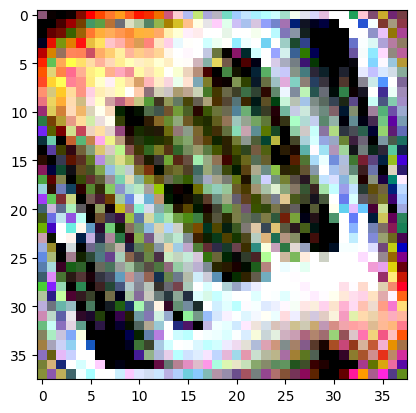

In [21]:
#Patch attack via optimization
# According to reference [1], one image is attacked each time
# Assert: applied patch should be a numpy
# Return the final perturbated picture and the applied patch. Their types are both numpy
def patch_attack(image, applied_patch, mask, target, probability_threshold, model, lr=1, max_iteration=100):
    model.eval()
    applied_patch = torch.from_numpy(applied_patch)
    mask = torch.from_numpy(mask)
    target_probability, count = 0, 0
    perturbated_image = torch.mul(mask.type(torch.FloatTensor), applied_patch.type(torch.FloatTensor)) + torch.mul((1 - mask.type(torch.FloatTensor)), image.type(torch.FloatTensor))
    while target_probability < probability_threshold and count < max_iteration:
        count += 1
        # Optimize the patch
        perturbated_image = Variable(perturbated_image.data, requires_grad=True)
        per_image = perturbated_image
        per_image = per_image.cuda()
        output = model(per_image)
        target_log_softmax = torch.nn.functional.log_softmax(output, dim=1)[0][target]
        target_log_softmax.backward()
        patch_grad = perturbated_image.grad.clone().cpu()
        perturbated_image.grad.data.zero_()
        applied_patch = lr * patch_grad + applied_patch.type(torch.FloatTensor)
        applied_patch = torch.clamp(applied_patch, min=-3, max=3)
        # Test the patch
        perturbated_image = torch.mul(mask.type(torch.FloatTensor), applied_patch.type(torch.FloatTensor)) + torch.mul((1-mask.type(torch.FloatTensor)), image.type(torch.FloatTensor))
        perturbated_image = torch.clamp(perturbated_image, min=-3, max=3)
        perturbated_image = perturbated_image.cuda()
        output = model(perturbated_image)
        target_probability = torch.nn.functional.softmax(output, dim=1).data[0][target]
    perturbated_image = perturbated_image.cpu().numpy()
    applied_patch = applied_patch.cpu().numpy()
    return perturbated_image, applied_patch

#os.environ["CUDA_VISIBLE_DEVICES"] = GPU

# Load the model
model = models.resnet50(pretrained=True).cuda()
model.eval()

# Load the datasets
train_loader, test_loader = dataloader(train_size, test_size, data_dir, batch_size, num_workers, 10000)

# Test the accuracy of model on trainset and testset
trainset_acc, test_acc = test(model, train_loader), test(model, test_loader)
print('Accuracy of the model on clean trainset and testset is {:.3f}% and {:.3f}%'.format(100*trainset_acc, 100*test_acc))

# Initialize the patch
patch = patch_initialization(patch_type, image_size=(3, 224, 224), noise_percentage=noise_percentage)
print('The shape of the patch is', patch.shape)

with open(log_dir, 'w') as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_success", "test_success"])

best_patch_epoch, best_patch_success_rate = 0, 0

# Generate the patch
for epoch in range(epochs):
    train_total, train_actual_total, train_success = 0, 0, 0
    for (image, label) in train_loader:
        train_total += label.shape[0]
        assert image.shape[0] == 1, 'Only one picture should be loaded each time.'
        image = image.cuda()
        label = label.cuda()
        output = model(image)
        _, predicted = torch.max(output.data, 1)
        if predicted[0] != label and predicted[0].data.cpu().numpy() != target:
             train_actual_total += 1
             applied_patch, mask, x_location, y_location = mask_generation(patch_type, patch, image_size=(3, 224, 224))
             perturbated_image, applied_patch = patch_attack(image, applied_patch, mask, target, probability_threshold, model, lr, max_iteration)
             perturbated_image = torch.from_numpy(perturbated_image).cuda()
             output = model(perturbated_image)
             _, predicted = torch.max(output.data, 1)
             if predicted[0].data.cpu().numpy() == target:
                 train_success += 1
             patch = applied_patch[0][:, x_location:x_location + patch.shape[1], y_location:y_location + patch.shape[2]]
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    plt.imshow(np.clip(np.transpose(patch, (1, 2, 0)) * std + mean, 0, 1))
    plt.savefig("training_pictures/" + str(epoch) + " patch.png")
    print("Epoch:{} Patch attack success rate on trainset: {:.3f}%".format(epoch, 100 * train_success / train_actual_total))
    train_success_rate = test_patch(patch_type, target, patch, test_loader, model)
    print("Epoch:{} Patch attack success rate on trainset: {:.3f}%".format(epoch, 100 * train_success_rate))
    test_success_rate = test_patch(patch_type, target, patch, test_loader, model)
    print("Epoch:{} Patch attack success rate on testset: {:.3f}%".format(epoch, 100 * test_success_rate))

    # Record the statistics
    with open(log_dir, 'a') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_success_rate, test_success_rate])

    if test_success_rate > best_patch_success_rate:
        best_patch_success_rate = test_success_rate
        best_patch_epoch = epoch
        plt.imshow(np.clip(np.transpose(patch, (1, 2, 0)) * std + mean, 0, 1))
        plt.savefig("training_pictures/best_patch.png")

    # Load the statistics and generate the line
    #log_generation(log_dir)

print("The best patch is found at epoch {} with success rate {}% on testset".format(best_patch_epoch, 100 * best_patch_success_rate))

In [19]:
torch.save(patch, "/home/nc3397/Work/MI/patches/GAP_38x38.pt")

In [ ]:
def img2double(img):
    info = np.finfo(img.dtype)
    return img.astype(float) / info.max


In [ ]:
def svd(img, full_matrices=False):
    U, S, VT = np.linalg.svd(img, full_matrices=full_matrices)
    return (U, np.diag(S), VT)


In [ ]:
def perc_storage(rank, n_rows, n_cols):
    original_space = n_rows*n_cols
    compressed_space = n_rows*rank + rank + n_cols*rank
    return compressed_space / original_space * 100


In [ ]:

def perc_energy(S, r):
    return (np.trace(S[:r]) / np.trace(S)) * 100


def frobenious_norm(A, B):
    return np.linalg.norm(A-B, ord='fro')



In [ ]:
def get_optimal_rank_by_energy(X, max_energy):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1

    while True:
        energy = perc_energy(S, opt_rank_)
        if energy < max_energy:
            opt_rank_ += 1
            continue
        if energy > max_energy:
            opt_rank_ -= 1

        break

    return opt_rank_


def get_optimal_rank_by_storage(X, max_storage):
    _, S, _ = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1

    while True:
        storage = perc_storage(opt_rank_, *S.shape)
        if storage < max_storage:
            opt_rank_ += 1
            continue
        if storage > max_storage:
            opt_rank_ -= 1

        break

    return opt_rank_


def get_optimal_rank_by_norm(X, max_norm):
    U, S, VT = svd(X)
    max_rank_ = S.shape[0]
    opt_rank_ = 1

    while True:
        X_r = U[:, :opt_rank_] @ S[:opt_rank_, :opt_rank_] @ VT[:opt_rank_, :]

        norm = frobenious_norm(X, X_r)
        if norm > max_norm:
            opt_rank_ += 1
            continue

        break

    return opt_rank_


In [ ]:
def get_optimal_rank(X, by='energy', **kwargs):
    VALID_BY = ['energy', 'storage', 'norm']

    if not isinstance(by, str):
        raise ValueError(f'by should be of type `str` but got {type(by)}')

    if by not in VALID_BY:
        raise ValueError(f'by should be one of {VALID_BY}')

    if by == 'energy':

        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_energy(X[:, :, 0], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 1], kwargs['max_energy']),
                    get_optimal_rank_by_energy(X[:, :, 2], kwargs['max_energy']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_energy(X, kwargs['max_energy'])

    elif by == 'storage':

        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_storage(X[:, :, 0], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 1], kwargs['max_storage']),
                    get_optimal_rank_by_storage(X[:, :, 2], kwargs['max_storage']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_storage(X, kwargs['max_storage'])

    else:

        if len(X.shape) == 3:
            opt_rank_ = np.mean(
                [
                    get_optimal_rank_by_norm(X[:, :, 0], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 1], kwargs['max_norm']),
                    get_optimal_rank_by_norm(X[:, :, 2], kwargs['max_norm']),
                ]
            )
        else:
            opt_rank_ = get_optimal_rank_by_norm(X, kwargs['max_norm'])

    return int(opt_rank_)

def calculate_mutual_information(chunk):
    """Calculate the mutual information score between a chunk and the full image."""
    flattened_chunk = chunk.ravel()
    #flattened_full_image = full_image.ravel()
    return mutual_info_score(flattened_chunk, flattened_chunk)

In [23]:
def split_image_into_chunks(image, window_size, step_size):
    """Split the image into chunks using a moving window."""
    chunks = view_as_windows(image, window_size, step_size)
    return chunks

def apply_svd_to_chunk(chunk, variance_retained):
    """Apply Singular Value Decomposition (SVD) to a chunk and retain enough singular values to preserve specified variance."""
    U, S, Vt = np.linalg.svd(chunk, full_matrices=False)
    total_variance = np.sum(S ** 2)
    variance_covered = 0
    k = 0
    while variance_covered / total_variance < variance_retained and k < len(S):
        variance_covered += S[k] ** 2
        k += 1
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    return U_k, S_k, Vt_k

In [ ]:
def reconstruct_chunk(U, S, Vt):
    """Reconstruct the chunk from its reduced SVD representation."""
    return np.dot(U, np.dot(np.diag(S), Vt))

def scale_to_ubyte(image):
    """Scale the image to 0-255 and convert to uint8."""
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return (image * 255).astype(np.uint8)

In [ ]:
def get_imagenet_dataloader(data_dir, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = datasets.ImageFolder(root=os.path.join('./val/'), transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

In [67]:
def main(image_path, window_size, step_size, variance_retained):
    # Read the image
    image = img_as_float(io.imread(image_path, as_gray=True))
    color_image = img_as_float(io.imread(image_path))

    # Split the image into chunks
    chunks = split_image_into_chunks(image, window_size, step_size)

    # Calculate mutual information score for each chunk
    mi_scores = np.zeros(chunks.shape[:2])
    for i in range(chunks.shape[0]):
        for j in range(chunks.shape[1]):
            mi_scores[i, j] = calculate_mutual_info_score(chunks[i, j])

    # Find the top 3 chunks with the highest mutual information scores
    top_indices = np.dstack(np.unravel_index(np.argsort(mi_scores.ravel())[-2:], mi_scores.shape))[0]
    top_chunks = [chunks[tuple(index)] for index in top_indices]

    # Apply SVD to the top chunks
    reconstructed_chunks = []
    for chunk in top_chunks:
        U, S, Vt = apply_svd_to_chunk(chunk, variance_retained)
        reconstructed_chunks.append(reconstruct_chunk(U, S, Vt))

    return color_image, mi_scores, top_indices, top_chunks, reconstructed_chunks

In [101]:
def MySVD(image, variability_perc):
    img = image.detach().cpu().numpy()
    max_energy=variability_perc
    max_storage=50
    max_norm=20

    opt_rank_by_energy = get_optimal_rank(img, by='energy', max_energy=max_energy)
    opt_rank_by_storage = get_optimal_rank(img, by='storage', max_storage=max_storage)
    opt_rank_by_norm = get_optimal_rank(img, by='norm', max_norm=max_norm)

    rank = opt_rank_by_energy

    RANKS = [rank]

    red_channel, green_channel, blue_channel =  img[:, :, 0], img[:, :, 1], img[:, :, 2]

    U_B, S_B, VT_B = svd(blue_channel)
    U_G, S_G, VT_G = svd(green_channel)
    U_R, S_R, VT_R = svd(red_channel)


    for idx, r in enumerate(RANKS):
        XR_r = U_R[:, :r] @ S_R[:r, :r] @ VT_R[:r, :]
        XG_r = U_G[:, :r] @ S_G[:r, :r] @ VT_G[:r, :]
        XB_r = U_B[:, :r] @ S_B[:r, :r] @ VT_B[:r, :]

        X_r = np.dstack((XR_r, XG_r, XB_r))

        info_stored = np.mean(
            [
                perc_energy(S_R, r),
                perc_energy(S_G, r),
                perc_energy(S_B, r),
            ]
        )

        frob_norm = np.mean(
                [
                    frobenious_norm(red_channel, XR_r),
                    frobenious_norm(green_channel, XG_r),
                    frobenious_norm(blue_channel, XB_r),
                ]
            )
    #print(rank)
    #print(frob_norm)
    img_dr = torch.from_numpy(np.transpose(X_r))
    img_dr = img_dr.cuda()
    return img_dr, rank


In [180]:
def visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size):
    """Visualize and save the color image with the chunks replaced by their SVD-reduced versions."""
    reconstructed_image = color_image.copy()
    for reconstructed_chunk, index in zip(reconstructed_chunks, top_indices):
        y = index[0] * step_size
        x = index[1] * step_size

        # Replace the chunk in all color channels
        for c in range(color_image.shape[2]):
            reconstructed_image[y:y+window_size[0], x:x+window_size[1], c] = reconstructed_chunk

        # Highlight the replaced chunk
        rect = plt.Rectangle((x, y), window_size[1], window_size[0],
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)

    # Scale the reconstructed image to 0-255 and convert to uint8
    reconstructed_image_uint8 = scale_to_ubyte(reconstructed_image)

    # Save the reconstructed image
    #io.imsave(output_path, reconstructed_image_uint8)

    # Visualize the image
    plt.imshow(reconstructed_image_uint8)
    #plt.show()
    return reconstructed_image_uint8



def process_image(image_path, window_size, step_size, variance_retained):
    color_image, mi_scores, top_indices, top_chunks, reconstructed_chunks = main(image_path, window_size, step_size, variance_retained)
    reconstructed_image = visualize_and_save_reconstructed_image_batch(color_image, reconstructed_chunks, top_indices, window_size, step_size)
    return reconstructed_image


In [102]:
def defense(input_path, output_path):
    new_number = -1
    path = os.listdir(input_path)
    path = natsorted(path)
    start_time = time.time()
    for filename in path:
        image_path = os.path.join(input_path, filename)
        processed_image = process_image(image_path,window_size, step_size, variance_retained)
        #file_name_without_extension, number = os.path.splitext(filename)[0], int(filename[-5:])
        new_number = new_number +1
        new_filename = f"defended_{new_number}.jpg"
        io.imsave(os.path.join(output_path, new_filename), processed_image)
        del processed_image
        gc.collect()
    end_time = time.time()
    execution_time = end_time - start_time  # Calculate time taken
    print(f"Execution Time: {execution_time:.4f} seconds")


